# Bibliotheque

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import RobustScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.decomposition import PCA
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.feature_selection import VarianceThreshold
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Dense
from sklearn.cluster import AgglomerativeClustering
from shapely.geometry import box
import tensorflow as tf
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import os
from sklearn.utils import shuffle

In [2]:
df = pd.read_csv("Cleaned_dataset/grid/MERGED_UNSUPERVED_long_lat.csv")

In [3]:
df = df.drop(columns=['Unnamed: 0', 'HWSD2_SMU_ID'], errors='ignore')
print(df.columns)
print(df.shape)

Index(['longitude', 'latitude', 'COARSE', 'SAND', 'SILT', 'CLAY', 'BULK',
       'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL',
       'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ',
       'GYPSUM', 'ELEC_COND', 'elevation', 'winter_prec', 'spring_prec',
       'summer_prec', 'autumn_prec', 'winter_tmax', 'spring_tmax',
       'summer_tmax', 'autumn_tmax', 'winter_tmin', 'spring_tmin',
       'summer_tmin', 'autumn_tmin', 'GRIDCODE_14.0', 'GRIDCODE_16.0',
       'GRIDCODE_20.0', 'GRIDCODE_30.0', 'GRIDCODE_41.0', 'GRIDCODE_50.0',
       'GRIDCODE_70.0', 'GRIDCODE_100.0', 'GRIDCODE_110.0', 'GRIDCODE_120.0',
       'GRIDCODE_130.0', 'GRIDCODE_134.0', 'GRIDCODE_150.0', 'GRIDCODE_151.0',
       'GRIDCODE_170.0', 'GRIDCODE_190.0', 'GRIDCODE_200.0', 'GRIDCODE_201.0',
       'GRIDCODE_202.0', 'GRIDCODE_203.0', 'GRIDCODE_210.0', 'TEXTURE_SOTER_C',
       'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M', 'fire_count'],
      dtype='object')
(845075, 60)


In [4]:
df

,longitude,latitude,COARSE,SAND,SILT,CLAY,BULK,REF_BULK,ORG_CARBON,PH_WATER,...,GRIDCODE_190.0,GRIDCODE_200.0,GRIDCODE_201.0,GRIDCODE_202.0,GRIDCODE_203.0,GRIDCODE_210.0,TEXTURE_SOTER_C,TEXTURE_SOTER_F,TEXTURE_SOTER_M,fire_count
0,-1.663868,34.000231,-0.615385,-0.466667,1.142857,0.000000,0.555555,-0.058823,-0.037691,0.133333,...,False,False,True,False,False,False,False,False,True,1.0
1,-1.663868,34.000231,0.538462,1.266667,-1.428571,-0.666667,-0.777778,-0.941177,-0.018846,-0.400000,...,False,False,True,False,False,False,True,False,False,1.0
2,-1.663868,34.000231,0.076923,0.666667,-0.714286,-0.333333,-0.111112,-0.411765,-0.130742,-0.133333,...,False,False,True,False,False,False,False,False,True,1.0
3,-1.663868,34.000231,0.384615,0.000000,-0.285714,0.250000,-0.222223,0.235294,-0.214370,0.200000,...,False,False,True,False,False,False,False,False,True,1.0
4,-1.653868,34.000231,-0.615385,-0.466667,1.142857,0.000000,0.555555,-0.058823,-0.037691,0.133333,...,False,False,True,False,False,False,False,False,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845070,9.736132,37.340231,0.538462,-0.466667,0.571429,0.333333,-0.222223,0.294117,0.531213,0.000000,...,False,False,False,False,False,False,False,False,True,0.0
845071,9.746132,37.340231,-0.153846,2.666667,-3.285714,-1.333333,0.000000,-3.058822,-0.116608,-1.533333,...,False,False,False,False,False,False,True,False,False,0.0
845072,9.746132,37.340231,0.538462,-0.466667,0.571429,0.333333,-0.222223,0.294117,0.531213,0.000000,...,False,False,False,False,False,False,False,False,True,0.0
845073,9.756132,37.340231,-0.153846,2.666667,-3.285714,-1.333333,0.000000,-3.058822,-0.116608,-1.533333,...,False,False,False,False,False,True,True,False,False,0.0


In [5]:
def extract_random_split_save(df, 
                              file_specific='Cleaned_dataset/unsupervised/long_lat_attributes.csv', 
                              file_rest='Cleaned_dataset/unsupervised/data.csv'):
    
    specific_attributes = ['longitude', 'latitude']
    
    missing_cols = [col for col in specific_attributes if col not in df.columns]
    if missing_cols:
        print(f"Error: The following columns are missing from the data: {missing_cols}")
        return

    df_specific = df[specific_attributes]
    
    df_rest = df.drop(columns=specific_attributes)
    
    df_specific.to_csv(file_specific, index=False)
    df_rest.to_csv(file_rest, index=False)
    
    print(f"Process Complete.")
    print(f"Total rows in original: {len(df)}")
    print(f"Rows in sample (100%): {len(df)}")
    print(f"Saved specific columns to: {file_specific}")
    print(f"Saved rest of data to: {file_rest}")



In [6]:
extract_random_split_save(df)
data_df = pd.read_csv('Cleaned_dataset/unsupervised/data.csv')
long_lat_df = pd.read_csv('Cleaned_dataset/unsupervised/long_lat_attributes.csv')

Process Complete.
Total rows in original: 845075
Rows in sample (100%): 845075
Saved specific columns to: Cleaned_dataset/unsupervised/long_lat_attributes.csv
Saved rest of data to: Cleaned_dataset/unsupervised/data.csv


In [7]:
print(data_df.shape)
print(long_lat_df.shape)

(845075, 58)
(845075, 2)


In [ ]:
def unsupervised_feature_reduction_kmeans(
    csv_path,
    var_threshold=0.01,
    cluster_distance=0.2,
):
    df = pd.read_csv(csv_path)

    if "fire" in df.columns:
        df = df.drop(columns=["fire"])

    print(f"Initial features: {df.shape[1]}")
 
    selector = VarianceThreshold(threshold=var_threshold)
    selector.fit(df)
    df = df.loc[:, selector.get_support()]
    print(f"After Variance Filter: {df.shape[1]}")
 
    corr_matrix = df.corr().abs()
    distance_matrix = 1 - corr_matrix

    clustering = AgglomerativeClustering(
        n_clusters=None,
        metric="precomputed",
        linkage="average",
        distance_threshold=cluster_distance,
        compute_distances=True,
    )
    clustering.fit(distance_matrix)
    cluster_labels = clustering.labels_

    selected_features = []
    for cluster_id in np.unique(cluster_labels):
        cluster_features = df.columns[cluster_labels == cluster_id]
        if len(cluster_features) == 1:
            selected_features.append(cluster_features[0])
        else:
            cluster_corr = corr_matrix.loc[cluster_features, cluster_features]
            best_feature = cluster_corr.sum().idxmax()
            selected_features.append(best_feature)

    df = df[selected_features]
    print(f"After Clustering: {df.shape[1]}")


    return df

df = unsupervised_feature_reduction_kmeans(csv_path="Cleaned_dataset/unsupervised/data.csv")
print(df.shape)
print(df.columns)


Initial features: 58
After Variance Filter: 47
After Clustering: 32
(845075, 32)
Index(['PH_WATER', 'ORG_CARBON', 'elevation', 'CLAY', 'CN_RATIO',
       'spring_tmax', 'TEXTURE_SOTER_C', 'spring_tmin', 'CEC_EFF', 'ESP',
       'TEXTURE_SOTER_M', 'GRIDCODE_151.0', 'TEXTURE_SOTER_F', 'spring_prec',
       'GRIDCODE_130.0', 'fire_count', 'GRIDCODE_201.0', 'GRIDCODE_50.0',
       'GRIDCODE_200.0', 'COARSE', 'ALUM_SAT', 'GRIDCODE_20.0', 'SILT',
       'summer_prec', 'GRIDCODE_14.0', 'GRIDCODE_150.0', 'autumn_prec', 'BULK',
       'CEC_CLAY', 'GRIDCODE_30.0', 'winter_prec', 'GRIDCODE_110.0'],
      dtype='object')


DATA SHAPE: (845075, 32)
K range: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

################################################################################
TRAINING KMEANS | K = 3
################################################################################
→ Fitting model on FULL dataset...
✓ Training completed
→ Computing Davies-Bouldin Index...
  Davies-Bouldin: 0.5232
→ Computing Calinski-Harabasz Index...
  Calinski-Harabasz: 959909.9932
→ Silhouette evaluation on 4 random 20% subsets
  Subset 1 | random_state=42
    Silhouette score: 0.6948
  Subset 2 | random_state=43
    Silhouette score: 0.6931
  Subset 3 | random_state=44
    Silhouette score: 0.6971
  Subset 4 | random_state=45
    Silhouette score: 0.6962
→ Average Silhouette (K=3): 0.6953
→ Saving clustered dataset...
✓ CSV saved: kmeans_models_outputs\data_kmeans_k3.csv

################################################################################
TRAINING KMEANS | K = 4
###################################

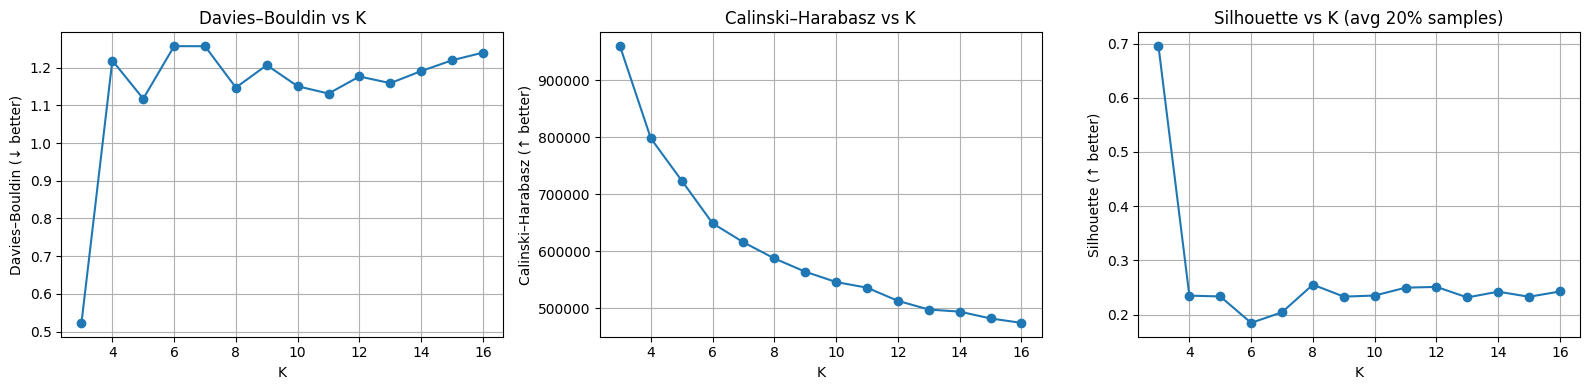

In [ ]:



# ==============================
# CONFIG
# ==============================
OUTPUT_DIR = "kmeans_models_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

K_RANGE = range(3, 17)
SILHOUETTE_SAMPLE_RATIO = 0.20
SILHOUETTE_REPEATS = 4
BASE_RANDOM_STATE = 42

X = df.values  # ensure numpy array

print("=" * 80)
print(f"DATA SHAPE: {X.shape}")
print(f"K range: {list(K_RANGE)}")
print("=" * 80)

results = []

# ==============================
# MAIN LOOP
# ==============================
for k in K_RANGE:
    print("\n" + "#" * 80)
    print(f"TRAINING KMEANS | K = {k}")
    print("#" * 80)

    # --------------------------
    # Train on FULL DATA
    # --------------------------
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=BASE_RANDOM_STATE
    )

    print("→ Fitting model on FULL dataset...")
    labels_full = kmeans.fit_predict(X)
    print("✓ Training completed")

    # --------------------------
    # Internal metrics (FULL DATA)
    # --------------------------
    print("→ Computing Davies-Bouldin Index...")
    db_index = davies_bouldin_score(X, labels_full)
    print(f"  Davies-Bouldin: {db_index:.4f}")

    print("→ Computing Calinski-Harabasz Index...")
    ch_index = calinski_harabasz_score(X, labels_full)
    print(f"  Calinski-Harabasz: {ch_index:.4f}")

    # --------------------------
    # Silhouette (SUBSAMPLING)
    # --------------------------
    silhouette_scores = []
    sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X))

    print(f"→ Silhouette evaluation on {SILHOUETTE_REPEATS} random 20% subsets")

    for i in range(SILHOUETTE_REPEATS):
        rs = BASE_RANDOM_STATE + i
        print(f"  Subset {i+1} | random_state={rs}")

        X_sub, labels_sub = shuffle(
            X, labels_full, random_state=rs
        )

        X_sub = X_sub[:sample_size]
        labels_sub = labels_sub[:sample_size]

        sil = silhouette_score(
            X_sub, labels_sub, metric="euclidean"
        )

        silhouette_scores.append(sil)
        print(f"    Silhouette score: {sil:.4f}")

    silhouette_avg = np.mean(silhouette_scores)
    print(f"→ Average Silhouette (K={k}): {silhouette_avg:.4f}")

    # --------------------------
    # Save clustered CSV
    # --------------------------
    print("→ Saving clustered dataset...")

    clustered_df = df.copy()
    clustered_df["cluster"] = labels_full

    output_path = os.path.join(
        OUTPUT_DIR, f"data_kmeans_k{k}.csv"
    )
    clustered_df.to_csv(output_path, index=False)

    print(f"✓ CSV saved: {output_path}")

    # --------------------------
    # Store results
    # --------------------------
    results.append({
        "k": k,
        "davies_bouldin": db_index,
        "calinski_harabasz": ch_index,
        "silhouette_avg": silhouette_avg
    })

# ==============================
# FINAL SUMMARY TABLE
# ==============================
results_df = pd.DataFrame(results)

print("\n" + "=" * 80)
print("FINAL METRICS SUMMARY")
print("=" * 80)
print(results_df)

summary_path = os.path.join(OUTPUT_DIR, "kmeans_metrics_summary.csv")
results_df.to_csv(summary_path, index=False)

print("\n✓ Metrics summary saved to:", summary_path)
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))

# Davies-Bouldin
plt.subplot(1, 3, 1)
plt.plot(results_df["k"], results_df["davies_bouldin"], marker="o")
plt.title("Davies–Bouldin vs K")
plt.xlabel("K")
plt.ylabel("Davies–Bouldin (↓ better)")
plt.grid(True)

# Calinski-Harabasz
plt.subplot(1, 3, 2)
plt.plot(results_df["k"], results_df["calinski_harabasz"], marker="o")
plt.title("Calinski–Harabasz vs K")
plt.xlabel("K")
plt.ylabel("Calinski–Harabasz (↑ better)")
plt.grid(True)

# Silhouette
plt.subplot(1, 3, 3)
plt.plot(results_df["k"], results_df["silhouette_avg"], marker="o")
plt.title("Silhouette vs K (avg 20% samples)")
plt.xlabel("K")
plt.ylabel("Silhouette (↑ better)")
plt.grid(True)

plt.tight_layout()
plt.show()


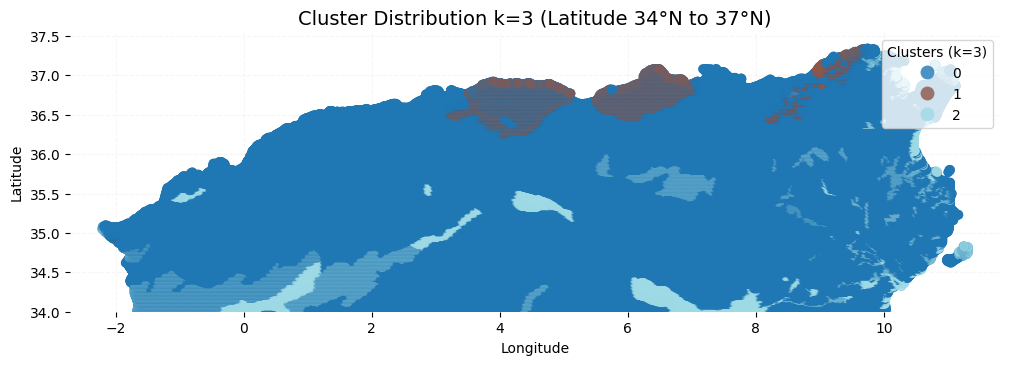

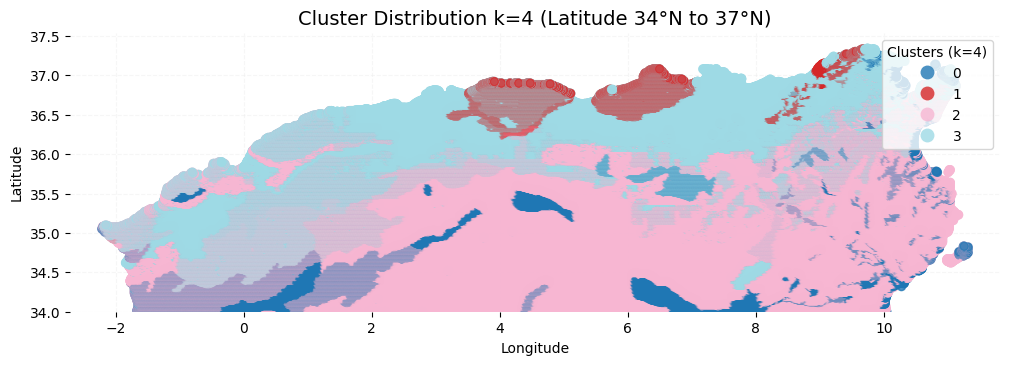

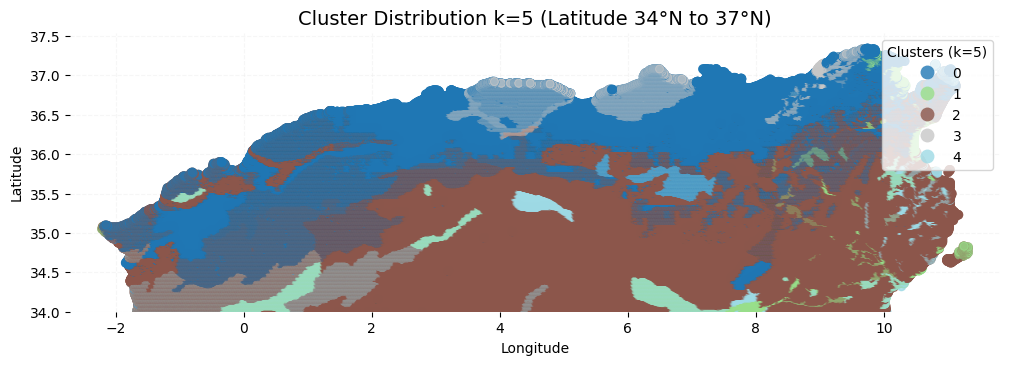

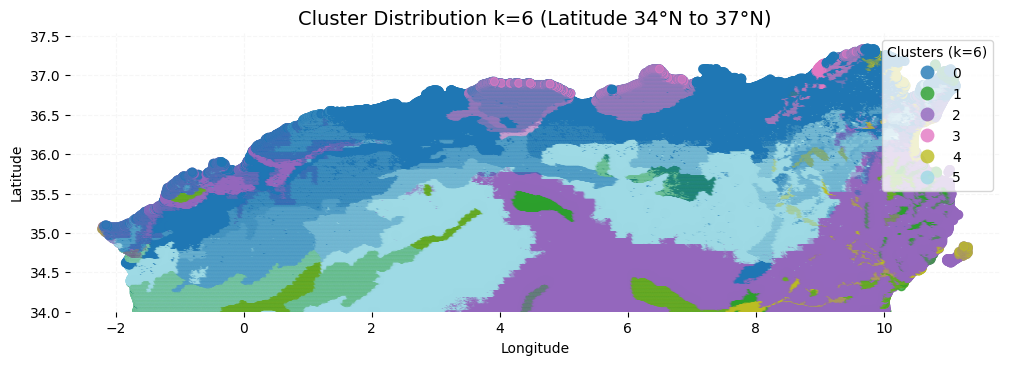

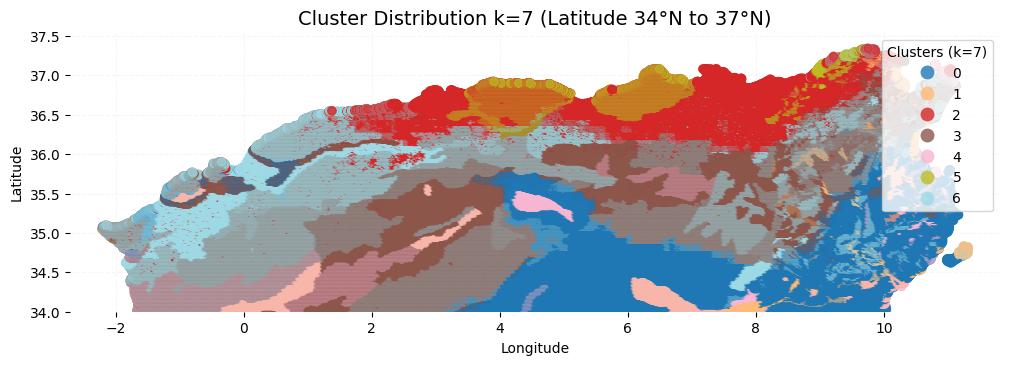

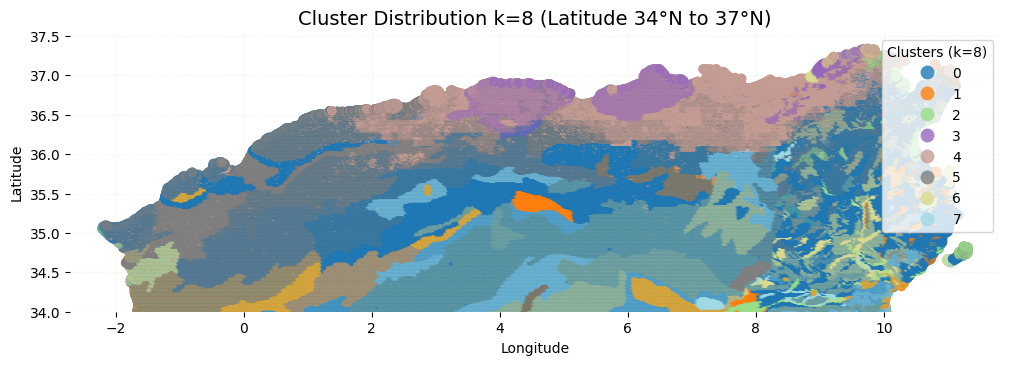

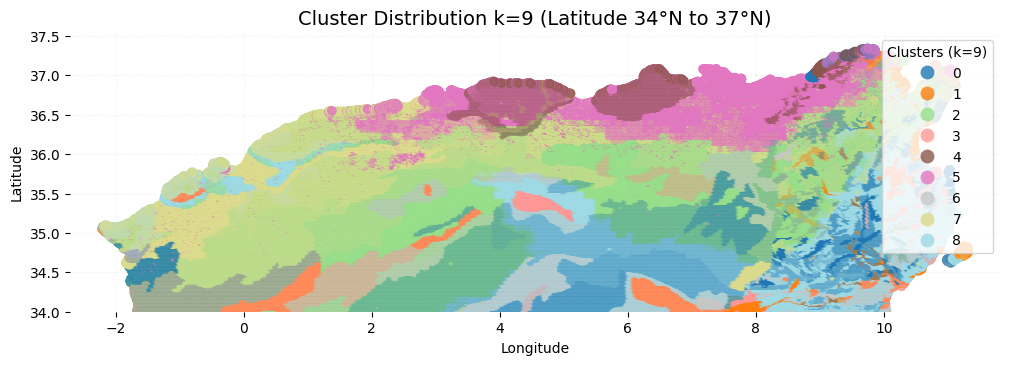

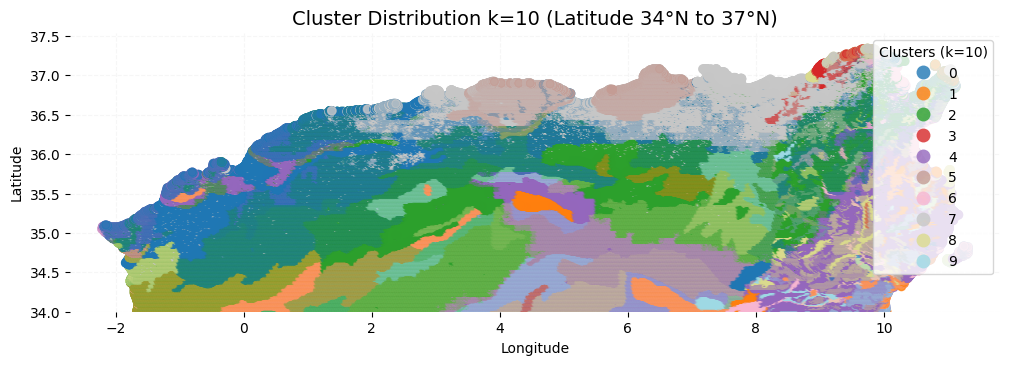

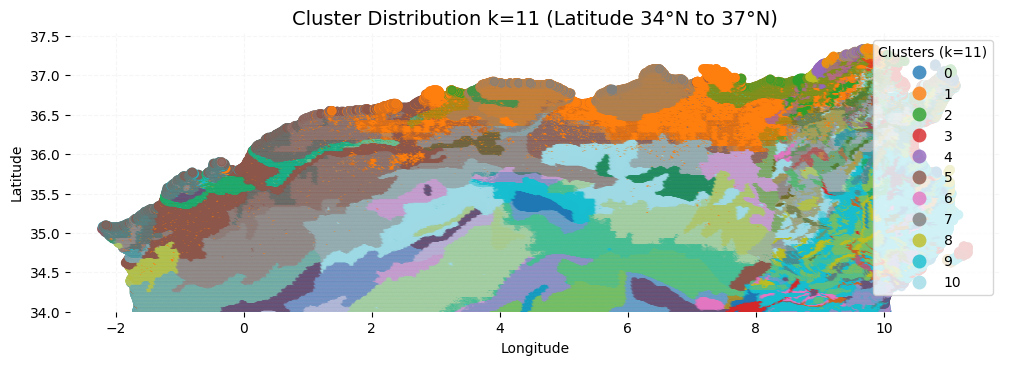

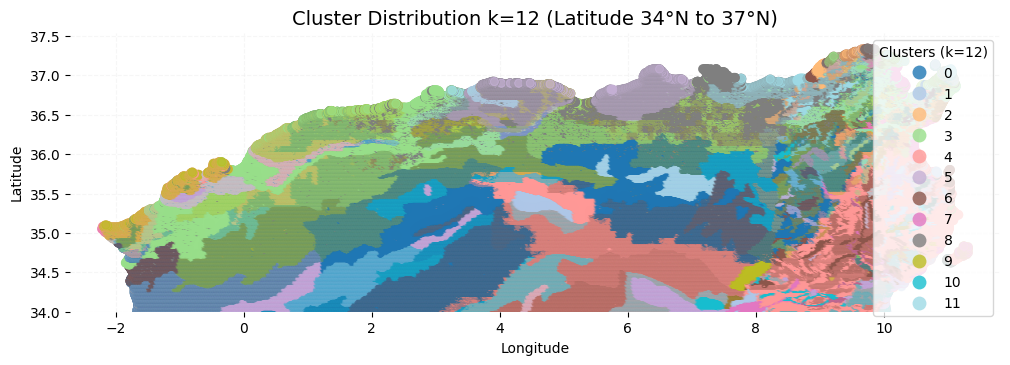

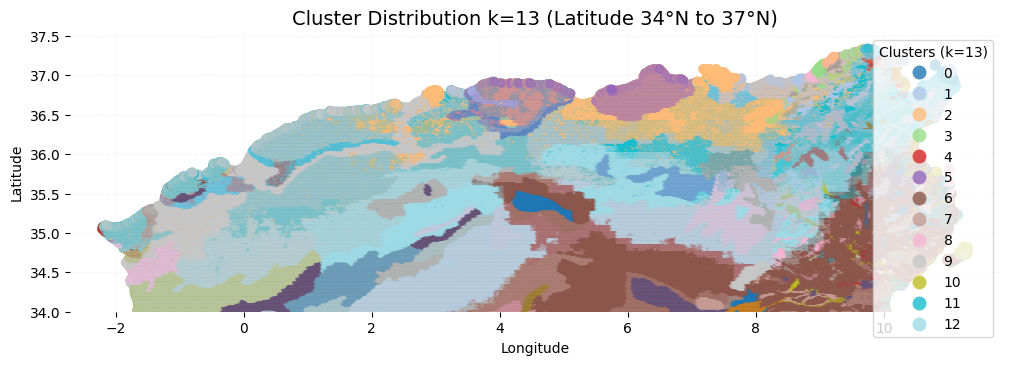

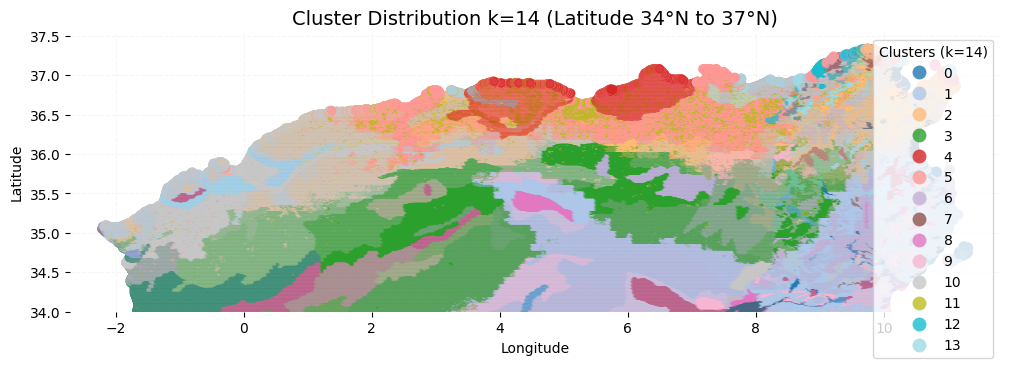

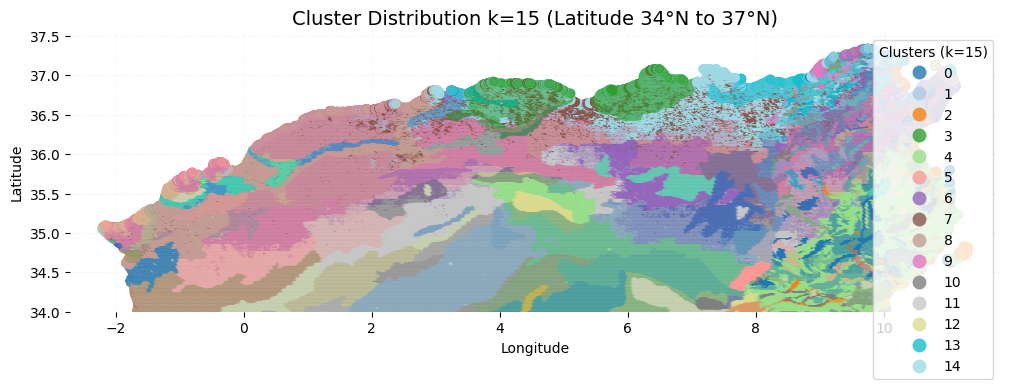

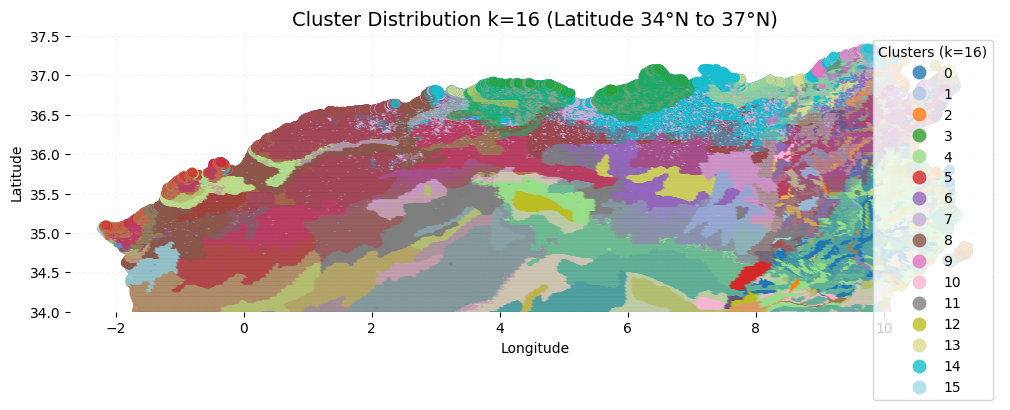

In [ ]:


# 1. Load coordinates (stays the same for all files)
coords = pd.read_csv("Cleaned_dataset/unsupervised/long_lat_attributes.csv")
lat_col = [c for c in coords.columns if 'lat' in c.lower()][0]
lon_col = [c for c in coords.columns if 'lon' in c.lower() or 'long' in c.lower()][0]

# 2. Prepare Map Data once (saves time and memory)
world_url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/world-countries.json"
world = gpd.read_file(world_url)
countries = world[world['name'].isin(["Algeria", "Tunisia"])]

# Clip map strictly to show Lat 34-40
xmin, ymin, xmax, ymax = countries.total_bounds
clipping_rect = box(xmin, 34, xmax, 40) 
countries_clipped = countries.clip(clipping_rect)

# 3. Loop through files from k=3 to k=16
for k in range(3, 17):
    file_path = f"kmeans_models_outputs/data_kmeans_k{k}.csv"
    
    # Check if file exists
    if not os.path.exists(file_path):
        continue

    # Load specific cluster file
    clusters = pd.read_csv(file_path)

    # Combine
    df = pd.concat([coords, clusters[['cluster']]], axis=1)

    # 4. Filter strictly for Latitude > 34
    df_filtered = df[df[lat_col] > 34].copy()

    # 5. Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df_filtered, 
        geometry=gpd.points_from_xy(df_filtered[lon_col], df_filtered[lat_col]),
        crs="EPSG:4326"
    )

    # 6. Plotting (Exact style from your code)
    fig, ax = plt.subplots(figsize=(12, 12)) 

    # NO BLACK: Land is white, borders are invisible
    countries_clipped.plot(ax=ax, color='white', edgecolor='none', zorder=1)

    # Plot the clusters 
    # (Using tab20 because you have up to 16 clusters)
    gdf.plot(column='cluster', 
             ax=ax, 
             categorical=True, 
             legend=True, 
             cmap='tab20', 
             markersize=35,      
             alpha=0.8,          
             zorder=2,
             legend_kwds={'title': f"Clusters (k={k})", 'loc': 'upper right'})

    # 7. VIEWPORT LOGIC: FORCE 34 to Max Lat
    ax.set_ylim(34, df_filtered[lat_col].max() + 0.2)
    ax.set_xlim(df_filtered[lon_col].min() - 0.5, df_filtered[lon_col].max() + 0.5)

    # Remove all black frame lines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Styling
    plt.title(f"Cluster Distribution k={k} (Latitude 34°N to 37°N)", fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    # Light grid
    ax.grid(True, linestyle='--', color='#eeeeee', alpha=0.5)

plt.show()

In [8]:
data_df = pd.read_csv('Cleaned_dataset/unsupervised/data.csv')

In [9]:
data_df

,COARSE,SAND,SILT,CLAY,BULK,REF_BULK,ORG_CARBON,PH_WATER,TOTAL_N,CN_RATIO,...,GRIDCODE_190.0,GRIDCODE_200.0,GRIDCODE_201.0,GRIDCODE_202.0,GRIDCODE_203.0,GRIDCODE_210.0,TEXTURE_SOTER_C,TEXTURE_SOTER_F,TEXTURE_SOTER_M,fire_count
0,-0.615385,-0.466667,1.142857,0.000000,0.555555,-0.058823,-0.037691,0.133333,-0.018518,-0.333333,...,False,False,True,False,False,False,False,False,True,1.0
1,0.538462,1.266667,-1.428571,-0.666667,-0.777778,-0.941177,-0.018846,-0.400000,-0.648148,1.000000,...,False,False,True,False,False,False,True,False,False,1.0
2,0.076923,0.666667,-0.714286,-0.333333,-0.111112,-0.411765,-0.130742,-0.133333,-0.370370,-0.333333,...,False,False,True,False,False,False,False,False,True,1.0
3,0.384615,0.000000,-0.285714,0.250000,-0.222223,0.235294,-0.214370,0.200000,-0.574074,0.333333,...,False,False,True,False,False,False,False,False,True,1.0
4,-0.615385,-0.466667,1.142857,0.000000,0.555555,-0.058823,-0.037691,0.133333,-0.018518,-0.333333,...,False,False,True,False,False,False,False,False,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
845070,0.538462,-0.466667,0.571429,0.333333,-0.222223,0.294117,0.531213,0.000000,-0.092593,-0.333333,...,False,False,False,False,False,False,False,False,True,0.0
845071,-0.153846,2.666667,-3.285714,-1.333333,0.000000,-3.058822,-0.116608,-1.533333,-0.759259,1.000000,...,False,False,False,False,False,False,True,False,False,0.0
845072,0.538462,-0.466667,0.571429,0.333333,-0.222223,0.294117,0.531213,0.000000,-0.092593,-0.333333,...,False,False,False,False,False,False,False,False,True,0.0
845073,-0.153846,2.666667,-3.285714,-1.333333,0.000000,-3.058822,-0.116608,-1.533333,-0.759259,1.000000,...,False,False,False,False,False,True,True,False,False,0.0


In [12]:
def analyze_correlation_variance(csv_path, target_col="fire", corr_threshold=0.9):
    """
    Loads dataset, computes correlation matrix, finds correlated pairs,
    and computes variance of each feature.
    """
    df = pd.read_csv(csv_path)

    # Remove target + coordinates if needed
    numeric_df = df.drop(columns=[target_col, "latitude", "longitude"], errors="ignore")

    # --- 1. Compute correlation matrix
    corr_matrix = numeric_df.corr().abs()

    # --- 2. Extract pairs above threshold
    correlated_pairs = []
    for col1 in corr_matrix.columns:
        for col2 in corr_matrix.columns:
            if col1 < col2:  # avoid repetition
                if corr_matrix.loc[col1, col2] >= corr_threshold:
                    correlated_pairs.append((col1, col2, corr_matrix.loc[col1, col2]))

    # --- 3. Variance of each feature
    variances = numeric_df.var().sort_values(ascending=True)

    return {
        "correlated_pairs": correlated_pairs,
        "variances": variances,
        "corr_matrix": corr_matrix,
    }

def unsupervised_feature_reduction(
    csv_path,
    output_path="reduced_dataset.csv",
    var_threshold=0.01,
    cluster_distance=0.3,
    use_autoencoder=False,
    n_ae_features=10,
    ae_epochs=50,
    percentage_data=1,  # example: 30% of data
):
    df = pd.read_csv(csv_path)

    if "fire" in df.columns:
        df = df.drop(columns=["fire"])
    df = df.sample(frac=percentage_data, random_state=42)
    print(f"Initial features: {df.shape[1]}")

    # ------------------------------------------------------------
    # 1️⃣ Remove Low-variance features
    # ------------------------------------------------------------
    selector = VarianceThreshold(threshold=var_threshold)
    selector.fit(df)
    df = df.loc[:, selector.get_support()]
    print(f"After Variance Filter: {df.shape[1]}")

    # ------------------------------------------------------------
    # 2️⃣ Feature Clustering
    # ------------------------------------------------------------
    corr_matrix = df.corr().abs()
    distance_matrix = 1 - corr_matrix

    clustering = AgglomerativeClustering(
        n_clusters=None,
        metric="precomputed",
        linkage="average",
        distance_threshold=cluster_distance,
        compute_distances=True,
    )
    clustering.fit(distance_matrix)
    cluster_labels = clustering.labels_

    selected_features = []
    for cluster_id in np.unique(cluster_labels):
        cluster_features = df.columns[cluster_labels == cluster_id]
        if len(cluster_features) == 1:
            selected_features.append(cluster_features[0])
        else:
            cluster_corr = corr_matrix.loc[cluster_features, cluster_features]
            best_feature = cluster_corr.sum().idxmax()
            selected_features.append(best_feature)

    df = df[selected_features]
    print(f"After Clustering: {df.shape[1]}")

    # ------------------------------------------------------------
    # 3️⃣ Optional: Autoencoder
    # ------------------------------------------------------------
    if use_autoencoder:
        print("Starting Autoencoder compression...")

        # Ensure the data is numeric and float32 for Keras
        try:
            X_input = df.astype("float32").values
        except ValueError as e:
            print("\n❌ DATA ERROR FOUND!")
            print("One column contains non-numeric data.")
            print("Run: print(df.dtypes[df.dtypes == 'object'])")
            raise e

        input_dim = X_input.shape[1]

        # ---------------------------
        # Autoencoder Architecture
        # ---------------------------

        input_layer = Input(shape=(input_dim,))

        # Encoder (deep encoder → better compression)
        e = Dense(128, activation="relu")(input_layer)
        e = Dense(64, activation="relu")(e)
        bottleneck = Dense(n_ae_features, activation="linear")(e)

        # Decoder (mirroring encoder)
        d = Dense(64, activation="relu")(bottleneck)
        d = Dense(128, activation="relu")(d)

        # *** IMPORTANT ***
        # Use linear output because your data includes StandardScaler features
        output_layer = Dense(input_dim, activation="linear")(d)

        # Build models
        autoencoder = Model(inputs=input_layer, outputs=output_layer)
        encoder = Model(inputs=input_layer, outputs=bottleneck)

        autoencoder.compile(optimizer="adam", loss="mse")

        # ---------------------------
        # Training (with validation)
        # ---------------------------

        history = autoencoder.fit(
            X_input,
            X_input,
            epochs=ae_epochs,
            batch_size=32,
            shuffle=True,
            validation_split=0.1,
            verbose=1,
        )

        plt.plot(history.history["loss"], label="train")
        plt.plot(history.history["val_loss"], label="val")
        plt.legend()
        plt.title("Autoencoder Reconstruction Loss")
        plt.show()

        # ---------------------------
        # Encode & Replace DF
        # ---------------------------

        encoded_data = encoder.predict(X_input)

        feat_cols = [f"ae_feature_{i}" for i in range(n_ae_features)]
        df = pd.DataFrame(encoded_data, columns=feat_cols)

        print(f"After Autoencoder: {df.shape[1]} synthetic features")

    df.to_csv(output_path, index=False)
    print(f"Saved to {output_path}")



Initial features: 58
After Variance Filter: 47
After Clustering: 32
Starting Autoencoder compression...
Epoch 1/50
23768/23768 ━━━━━━━━━━━━━━━━━━━━ 74s 3ms/step - loss: 0.0152 - val_loss: 0.0064
Epoch 2/50
23768/23768 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - loss: 0.0053 - val_loss: 0.0036
Epoch 3/50
23768/23768 ━━━━━━━━━━━━━━━━━━━━ 69s 3ms/step - loss: 0.0031 - val_loss: 0.0024
Epoch 4/50
23768/23768 ━━━━━━━━━━━━━━━━━━━━ 72s 3ms/step - loss: 0.0024 - val_loss: 0.0016
Epoch 5/50
23768/23768 ━━━━━━━━━━━━━━━━━━━━ 70s 3ms/step - loss: 0.0020 - val_loss: 0.0032
Epoch 6/50
23768/23768 ━━━━━━━━━━━━━━━━━━━━ 71s 3ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 7/50
23768/23768 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - loss: 0.0015 - val_loss: 9.5042e-04
Epoch 8/50
23768/23768 ━━━━━━━━━━━━━━━━━━━━ 68s 3ms/step - loss: 0.0014 - val_loss: 8.4030e-04
Epoch 9/50
23768/23768 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step - loss: 0.0012 - val_loss: 8.5783e-04
Epoch 10/50
23768/23768 ━━━━━━━━━━━━━━━━━━━━ 65s 3ms/step - loss:

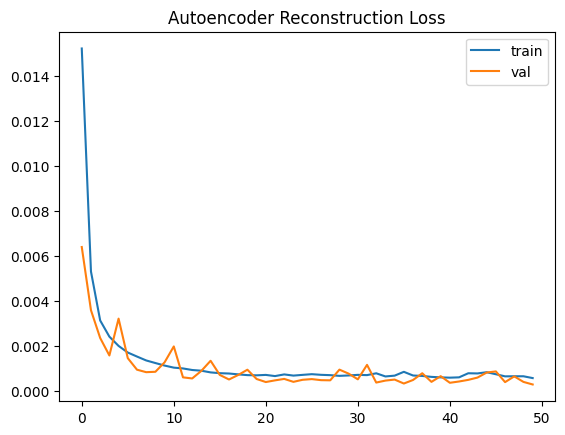

26409/26409 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step
After Autoencoder: 10 synthetic features
Saved to Cleaned_dataset/unsupervised/preprocessed_reduced_data_unsupervised_10.csv


In [15]:

nb_features = 10
unsupervised_feature_reduction(
    csv_path="Cleaned_dataset/unsupervised/data.csv",
    output_path=f"Cleaned_dataset/unsupervised/preprocessed_reduced_data_unsupervised_{nb_features}.csv",
    var_threshold=0.01,
    cluster_distance=0.2,
    use_autoencoder=True,
    n_ae_features=nb_features,
    ae_epochs=50,
)

In [ ]:
INPUT_CSV = "Cleaned_dataset/unsupervised/preprocessed_reduced_data_unsupervised_10.csv"
OUTPUT_DIR = "dbscan_models_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# PARAMÈTRES À TESTER (OPTIMISÉS POUR 800k x 10)
EPS_RANGE = [0.2, 0.3, 0.5, 0.6, 0.7]
MIN_SAMPLES_LIST = [15, 20]

df = pd.read_csv(INPUT_CSV)

X = df.values.astype(np.float32)

print("Data shape:", X.shape)
print("✓ Data assumed already normalized (NO SCALING APPLIED)")

# ÉVALUATION
SILHOUETTE_SAMPLE_RATIO = 0.1   # 5% suffit largement
SILHOUETTE_REPEATS = 3
BASE_RANDOM_STATE = 42

results = []

for min_samples in MIN_SAMPLES_LIST:
    for eps in EPS_RANGE:
        print("\n" + "#" * 80)
        print(f"DBSCAN | eps={eps:.2f} | min_samples={min_samples}")
        print("#" * 80)

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean",
            algorithm="ball_tree",
            n_jobs=-1
        )

        labels = dbscan.fit_predict(X)

        # --------------------------
        # Analyse clusters
        # --------------------------
        n_clusters = len(set(labels) - {-1})
        noise_ratio = np.mean(labels == -1)

        print(f"Clusters (sans bruit): {n_clusters}")
        print(f"Noise ratio: {noise_ratio:.2%}")

        db_index = np.nan
        ch_index = np.nan
        silhouette_avg = np.nan

        # --------------------------
        # Retirer le bruit
        # --------------------------
        mask = labels != -1
        X_clean = X[mask]
        labels_clean = labels[mask]

        if len(np.unique(labels_clean)) >= 2:
            print("→ Computing internal metrics...")

            db_index = davies_bouldin_score(X_clean, labels_clean)
            ch_index = calinski_harabasz_score(X_clean, labels_clean)

            # --------------------------
            # Silhouette (subsampling)
            # --------------------------
            silhouette_scores = []
            sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X_clean))

            for i in range(SILHOUETTE_REPEATS):
                rs = BASE_RANDOM_STATE + i

                X_sub, labels_sub = shuffle(
                    X_clean, labels_clean, random_state=rs
                )

                X_sub = X_sub[:sample_size]
                labels_sub = labels_sub[:sample_size]

                sil = silhouette_score(X_sub, labels_sub)
                silhouette_scores.append(sil)

            silhouette_avg = np.mean(silhouette_scores)

            print(f"Davies-Bouldin: {db_index:.4f}")
            print(f"Calinski-Harabasz: {ch_index:.2f}")
            print(f"Silhouette avg: {silhouette_avg:.4f}")

        else:
            print("⚠ Pas assez de clusters pour calculer les métriques")

        # --------------------------
        # Sauvegarde CSV
        # --------------------------
        clustered_df = df.copy()
        clustered_df["cluster"] = labels

        out_csv = os.path.join(
            OUTPUT_DIR,
            f"data_dbscan_eps{eps:.2f}_min{min_samples}.csv"
        )
        clustered_df.to_csv(out_csv, index=False)

        print("✓ CSV saved:", out_csv)

        # --------------------------
        # Stocker résultats
        # --------------------------
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "davies_bouldin": db_index,
            "calinski_harabasz": ch_index,
            "silhouette_avg": silhouette_avg
        })

results_df = pd.DataFrame(results)

summary_path = os.path.join(
    OUTPUT_DIR, "dbscan_metrics_summary.csv"
)
results_df.to_csv(summary_path, index=False)

print("\n" + "=" * 80)
print("FINAL DBSCAN SUMMARY")
print("=" * 80)
print(results_df)
print("\n✓ Metrics saved to:", summary_path)


Data shape: (845075, 10)
✓ Data assumed already normalized (NO SCALING APPLIED)

################################################################################
DBSCAN | eps=0.20 | min_samples=15
################################################################################
Clusters (sans bruit): 1472
Noise ratio: 5.86%
→ Computing internal metrics...
Davies-Bouldin: 0.7821
Calinski-Harabasz: 12508.79
Silhouette avg: 0.2083
✓ CSV saved: dbscan_models_outputs\data_dbscan_eps0.20_min15.csv

################################################################################
DBSCAN | eps=0.30 | min_samples=15
################################################################################
Clusters (sans bruit): 1042
Noise ratio: 2.83%
→ Computing internal metrics...
Davies-Bouldin: 0.8927
Calinski-Harabasz: 12545.00
Silhouette avg: 0.1848
✓ CSV saved: dbscan_models_outputs\data_dbscan_eps0.30_min15.csv

################################################################################
DBSCAN

In [ ]:
plt.figure(figsize=(18, 5))

# Nombre de clusters
plt.subplot(1, 4, 1)
plt.plot(results_df["eps"], results_df["n_clusters"], "o-")
plt.xlabel("eps")
plt.ylabel("Clusters")
plt.title("Clusters vs eps")
plt.grid(True)

# Bruit
plt.subplot(1, 4, 2)
plt.plot(results_df["eps"], results_df["noise_ratio"], "o-")
plt.xlabel("eps")
plt.ylabel("Noise ratio")
plt.title("Noise ratio vs eps")
plt.grid(True)

# Davies-Bouldin
plt.subplot(1, 4, 3)
plt.plot(results_df["eps"], results_df["davies_bouldin"], "o-")
plt.xlabel("eps")
plt.ylabel("Davies–Bouldin ↓")
plt.title("Davies–Bouldin vs eps")
plt.grid(True)

# Silhouette
plt.subplot(1, 4, 4)
plt.plot(results_df["eps"], results_df["silhouette_avg"], "o-")
plt.xlabel("eps")
plt.ylabel("Silhouette ↑")
plt.title("Silhouette vs eps")
plt.grid(True)

plt.tight_layout()
plt.show()


In [4]:
import os
import numpy as np
import pandas as pd

from hdbscan import HDBSCAN
from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score,
    silhouette_score
)
from sklearn.utils import shuffle

# ==============================
# CONFIG
# ==============================
INPUT_CSV = "Cleaned_dataset/unsupervised/preprocessed_reduced_data_unsupervised_10.csv"
OUTPUT_DIR = "hdbscan_models_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# PARAMÈTRES À TESTER (800k x 10)
MIN_CLUSTER_SIZE_LIST = [50, 100, 200]
MIN_SAMPLES_LIST = [10, 20, 30]

SILHOUETTE_SAMPLE_RATIO = 0.1
SILHOUETTE_REPEATS = 3
BASE_RANDOM_STATE = 42

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv(INPUT_CSV)
X = df.values.astype(np.float32)

print("Data shape:", X.shape)
print("✓ Data assumed already normalized")

results = []

# ==============================
# GRID SEARCH HDBSCAN
# ==============================
for min_cluster_size in MIN_CLUSTER_SIZE_LIST:
    for min_samples in MIN_SAMPLES_LIST:
        print("\n" + "#" * 80)
        print(f"HDBSCAN | min_cluster_size={min_cluster_size} | min_samples={min_samples}")
        print("#" * 80)

        hdbscan = HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric="euclidean",
            cluster_selection_method="eom",
            core_dist_n_jobs=-1
        )

        labels = hdbscan.fit_predict(X)

        # --------------------------
        # Analyse clusters
        # --------------------------
        n_clusters = len(set(labels) - {-1})
        noise_ratio = np.mean(labels == -1)

        print(f"Clusters (sans bruit): {n_clusters}")
        print(f"Noise ratio: {noise_ratio:.2%}")

        db_index = np.nan
        ch_index = np.nan
        silhouette_avg = np.nan

        # --------------------------
        # Retirer le bruit
        # --------------------------
        mask = labels != -1
        X_clean = X[mask]
        labels_clean = labels[mask]

        if len(np.unique(labels_clean)) >= 2:
            print("→ Computing internal metrics...")

            db_index = davies_bouldin_score(X_clean, labels_clean)
            ch_index = calinski_harabasz_score(X_clean, labels_clean)

            # --------------------------
            # Silhouette (subsampling)
            # --------------------------
            silhouette_scores = []
            sample_size = int(SILHOUETTE_SAMPLE_RATIO * len(X_clean))

            for i in range(SILHOUETTE_REPEATS):
                rs = BASE_RANDOM_STATE + i

                X_sub, labels_sub = shuffle(
                    X_clean, labels_clean, random_state=rs
                )

                X_sub = X_sub[:sample_size]
                labels_sub = labels_sub[:sample_size]

                sil = silhouette_score(X_sub, labels_sub)
                silhouette_scores.append(sil)

            silhouette_avg = np.mean(silhouette_scores)

            print(f"Davies-Bouldin: {db_index:.4f}")
            print(f"Calinski-Harabasz: {ch_index:.2f}")
            print(f"Silhouette avg: {silhouette_avg:.4f}")
        else:
            print("⚠ Pas assez de clusters pour calculer les métriques")

        # --------------------------
        # Sauvegarde CSV (cluster par ligne)
        # --------------------------
        clustered_df = df.copy()
        clustered_df["cluster"] = labels

        out_csv = os.path.join(
            OUTPUT_DIR,
            f"data_hdbscan_mcs{min_cluster_size}_ms{min_samples}.csv"
        )
        clustered_df.to_csv(out_csv, index=False)

        print("✓ CSV saved:", out_csv)

        # --------------------------
        # Stocker résultats
        # --------------------------
        results.append({
            "min_cluster_size": min_cluster_size,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "davies_bouldin": db_index,
            "calinski_harabasz": ch_index,
            "silhouette_avg": silhouette_avg
        })

# ==============================
# SUMMARY
# ==============================
results_df = pd.DataFrame(results)

summary_path = os.path.join(
    OUTPUT_DIR, "hdbscan_metrics_summary.csv"
)
results_df.to_csv(summary_path, index=False)

print("\n" + "=" * 80)
print("FINAL HDBSCAN SUMMARY")
print("=" * 80)
print(results_df)
print("\n✓ Metrics saved to:", summary_path)


Data shape: (845075, 10)
✓ Data assumed already normalized

################################################################################
HDBSCAN | min_cluster_size=50 | min_samples=10
################################################################################
Clusters (sans bruit): 5003
Noise ratio: 16.78%
→ Computing internal metrics...
Davies-Bouldin: 0.8889
Calinski-Harabasz: 7127.87
Silhouette avg: 0.3615
✓ CSV saved: hdbscan_models_outputs\data_hdbscan_mcs50_ms10.csv

################################################################################
HDBSCAN | min_cluster_size=50 | min_samples=20
################################################################################
Clusters (sans bruit): 4243
Noise ratio: 19.05%
→ Computing internal metrics...
Davies-Bouldin: 0.8112
Calinski-Harabasz: 7250.99
Silhouette avg: 0.3666
✓ CSV saved: hdbscan_models_outputs\data_hdbscan_mcs50_ms20.csv

################################################################################
HDBSC